# 🚌 5/6차시 실습 — 버스 혼잡도 데이터 분석

이 노트북은 **위에서 아래로 순서대로** 실행합니다.  
코드를 직접 작성할 필요는 없습니다.  
**`___` 표시된 부분만** 학습지를 보고 숫자를 채워 넣으세요.

> 셀 실행 방법 : 셀 왼쪽의 ▶ 버튼을 누르거나 `Shift + Enter`를 누릅니다.

---
## [준비 1] 필요한 도구 불러오기

가장 먼저 실행합니다. 이 셀은 수정하지 않습니다.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import urllib.request

# 한글 폰트 다운로드 및 설정
url = 'https://github.com/google/fonts/raw/main/ofl/notosanskr/NotoSansKR%5Bwght%5D.ttf'
font_path = '/tmp/NotoSansKR.ttf'
urllib.request.urlretrieve(url, font_path)

fe = fm.FontEntry(fname=font_path, name='NotoSansKR')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = 'NotoSansKR'
plt.rcParams['axes.unicode_minus'] = False

print('✅ 준비 완료!')

✅ 준비 완료!


---
## [준비 2] 데이터 불러오기

왼쪽 사이드바의 📁 폴더 아이콘을 눌러 파일 탐색기를 열고,  
선생님이 제공한 `bus_merged.csv` 파일을 드래그하여 업로드한 뒤 아래 셀을 실행합니다.

In [15]:
df = pd.read_csv('bus_merged.csv', encoding='utf-8-sig')

print('✅ 파일 읽기 완료!')

✅ 파일 읽기 완료!


---
## [실습 ①] 데이터 구조 확인하기

아래 셀을 실행하면 데이터의 첫 5줄과 전체 크기, 컬럼 목록이 출력됩니다.  
출력 결과를 보고 학습지의 빈칸을 채웁니다.

In [16]:
print('=== 데이터 미리보기 (첫 5줄) ===')
display(df.head())

print(f'\n=== 데이터 크기 ===')
print(f'전체 행(줄) 수 : {len(df):,} 개')
print(f'전체 컬럼(열) 수 : {len(df.columns)} 개')

print(f'\n=== 컬럼 이름 목록 ===')
for col in df.columns:
    print(f'  - {col}')

=== 데이터 미리보기 (첫 5줄) ===


,사용년월,정류장ARS번호,역명,hour,승차총승객수,하차총승객수
0,202504,23849,한남대교(가상)(00015),0,0,0
1,202504,23849,한남대교(가상)(00029),0,0,3
2,202504,23849,한남대교(가상)(00039),0,0,0
3,202504,23850,한남대교(가상)(00011),0,0,0
4,202504,23850,한남대교(가상)(00027),0,0,0



=== 데이터 크기 ===
전체 행(줄) 수 : 165,480 개
전체 컬럼(열) 수 : 6 개

=== 컬럼 이름 목록 ===
  - 사용년월
  - 정류장ARS번호
  - 역명
  - hour
  - 승차총승객수
  - 하차총승객수


---
## [실습 ②] 시간대별 패턴 파악하기

아래 셀을 실행하면 시간대(0시~23시)별 평균 승하차 인원 막대그래프가 나타납니다.  
가장 높은 막대는 빨간색으로 강조됩니다.  
그래프를 관찰하고 학습지의 빈칸을 채웁니다.

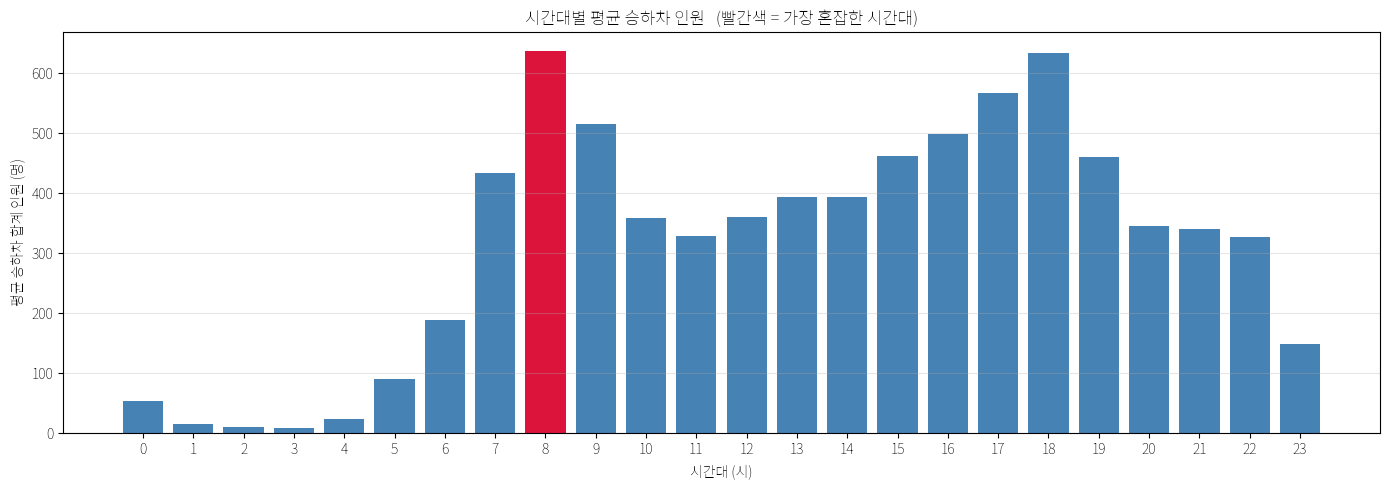

승하차 인원이 가장 많은 시간대     : 8시  (평균 637명)
승하차 인원이 두 번째로 많은 시간대 : 18시  (평균 634명)
승하차 인원이 가장 적은 시간대     : 3시  (평균 8명)


In [17]:
df['total'] = df['승차총승객수'] + df['하차총승객수']
hourly = df.groupby('hour')['total'].mean()

plt.figure(figsize=(14, 5))
colors = ['crimson' if h == hourly.idxmax() else 'steelblue' for h in hourly.index]
plt.bar(hourly.index, hourly.values, color=colors)

plt.xlabel('시간대 (시)')
plt.ylabel('평균 승하차 합계 인원 (명)')
plt.title('시간대별 평균 승하차 인원   (빨간색 = 가장 혼잡한 시간대)')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

sorted_hourly = hourly.sort_values(ascending=False)
print(f'승하차 인원이 가장 많은 시간대     : {sorted_hourly.index[0]}시  (평균 {sorted_hourly.iloc[0]:.0f}명)')
print(f'승하차 인원이 두 번째로 많은 시간대 : {sorted_hourly.index[1]}시  (평균 {sorted_hourly.iloc[1]:.0f}명)')
print(f'승하차 인원이 가장 적은 시간대     : {hourly.idxmin()}시  (평균 {hourly.min():.0f}명)')

---
## [실습  ③] 필요한 컬럼만 남기기 (전처리)

아래 셀을 실행하면 `hour`, `stop_id(정류장ARS번호)`, `stop_name(역명)`, `total` 네 컬럼만 남고 나머지는 제거됩니다.  
전처리 전후의 컬럼 수를 확인하고 학습지의 빈칸을 채웁니다.

In [18]:
print(f'전처리 전 컬럼 수 : {len(df.columns)} 개')
print(f'컬럼 목록 : {list(df.columns)}\n')

df_clean = df[['hour', '정류장ARS번호', '역명', 'total']].copy()
df_clean.columns = ['hour', 'stop_id', 'stop_name', 'total']
df_clean = df_clean.dropna()

print(f'전처리 후 컬럼 수 : {len(df_clean.columns)} 개  (hour, stop_id, stop_name, total)')
print(f'컬럼 목록 : {list(df_clean.columns)}\n')

print('=== 전처리 후 데이터 미리보기 ===')
display(df_clean.head())

print(f'\ntotal 최솟값 : {df_clean["total"].min():.0f}명')
print(f'total 최댓값 : {df_clean["total"].max():.0f}명')
print(f'total 평균   : {df_clean["total"].mean():.0f}명')

전처리 전 컬럼 수 : 7 개
컬럼 목록 : ['사용년월', '정류장ARS번호', '역명', 'hour', '승차총승객수', '하차총승객수', 'total']

전처리 후 컬럼 수 : 4 개  (hour, stop_id, stop_name, total)
컬럼 목록 : ['hour', 'stop_id', 'stop_name', 'total']

=== 전처리 후 데이터 미리보기 ===


,hour,stop_id,stop_name,total
0,0,23849,한남대교(가상)(00015),0
1,0,23849,한남대교(가상)(00029),3
2,0,23849,한남대교(가상)(00039),0
3,0,23850,한남대교(가상)(00011),0
4,0,23850,한남대교(가상)(00027),0



total 최솟값 : 0명
total 최댓값 : 8060명
total 평균   : 316명


---
## [실습 ④] 혼잡도 기준 탐색하기

아래 셀을 실행하면 `total` 값의 분포 그래프가 나타납니다.  
주황색 점선과 빨간색 점선은 데이터를 균등하게 세 구간으로 나누는 참고 기준선입니다.  
참고값을 학습지에 기록하고, 조원과 함께 우리 조의 기준을 논의합니다.

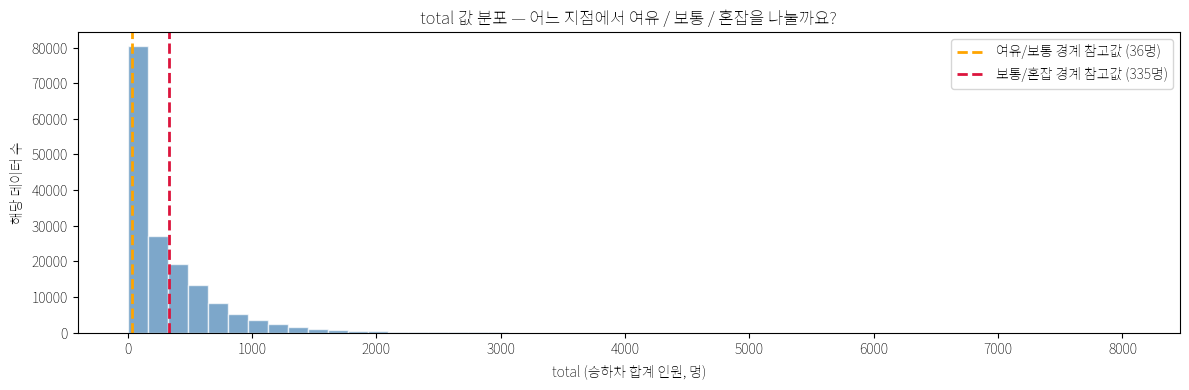

여유/보통 경계 참고값 : 36명
보통/혼잡 경계 참고값 : 335명

※ 반드시 이 값을 사용할 필요는 없습니다. 조원과 논의하여 우리 조만의 기준을 정해보세요.


In [19]:
p33 = df_clean['total'].quantile(0.33)
p66 = df_clean['total'].quantile(0.66)

plt.figure(figsize=(12, 4))
plt.hist(df_clean['total'], bins=50, color='steelblue', alpha=0.7, edgecolor='white')
plt.axvline(p33, color='orange', linestyle='--', linewidth=2, label=f'여유/보통 경계 참고값 ({p33:.0f}명)')
plt.axvline(p66, color='crimson', linestyle='--', linewidth=2, label=f'보통/혼잡 경계 참고값 ({p66:.0f}명)')

plt.xlabel('total (승하차 합계 인원, 명)')
plt.ylabel('해당 데이터 수')
plt.title('total 값 분포 — 어느 지점에서 여유 / 보통 / 혼잡을 나눌까요?')
plt.legend()
plt.tight_layout()
plt.show()

print(f'여유/보통 경계 참고값 : {p33:.0f}명')
print(f'보통/혼잡 경계 참고값 : {p66:.0f}명')
print('\n※ 반드시 이 값을 사용할 필요는 없습니다. 조원과 논의하여 우리 조만의 기준을 정해보세요.')

---
## [실습 ⑤,⑥] 레이블 생성 및 결과 확인하기 ★

학습지 실습 ④에서 정한 기준 숫자를 아래 `___` 두 곳에 입력하고 셀을 실행합니다.  
**이 두 줄만 수정하면 됩니다.**

In [20]:
# ✏️ 여기만 수정하세요 ⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐


여유_기준 = 20  # 이 숫자 미만이면 → 여유 (0)
혼잡_기준 = 100   # 이 숫자 이상이면 → 혼잡 (2)  /  그 사이는 자동으로 보통 (1)


# ---- 아래는 수정하지 않습니다 ----

def 혼잡도_분류(total):
    if total < 여유_기준:
        return 0
    elif total >= 혼잡_기준:
        return 2
    else:
        return 1

df_clean['label'] = df_clean['total'].apply(혼잡도_분류)

counts = df_clean['label'].value_counts().sort_index()
total_count = len(df_clean)

print('=== 레이블 생성 완료 ===')
names = {0: '🟢 여유 (0)', 1: '🟡 보통 (1)', 2: '🔴 혼잡 (2)'}
for label, count in counts.items():
    pct = count / total_count * 100
    bar = '█' * int(pct / 2)
    print(f'{names[label]:12s} : {count:6,}개   ({pct:5.1f}%)   {bar}')

print(f'\n우리 조 기준 : {여유_기준}명 미만 = 여유  /  {여유_기준}~{혼잡_기준}명 = 보통  /  {혼잡_기준}명 이상 = 혼잡')

=== 레이블 생성 완료 ===
🟢 여유 (0)     : 50,935개   ( 30.8%)   ███████████████
🟡 보통 (1)     : 16,972개   ( 10.3%)   █████
🔴 혼잡 (2)     : 97,573개   ( 59.0%)   █████████████████████████████

우리 조 기준 : 20명 미만 = 여유  /  20~100명 = 보통  /  100명 이상 = 혼잡


---
## [실습 ⑦] 파일 저장 및 내려받기

아래 셀을 실행하면 `bus_labeled.csv` 파일이 생성되고 내 컴퓨터에 자동으로 내려받아집니다.  
내려받기가 시작되지 않는 경우, 왼쪽 사이드바의 파일 탐색기에서 `bus_labeled.csv`를 마우스 오른쪽 버튼으로 클릭하고 '다운로드'를 선택합니다.

> 📌 이 파일은 7/8차시 AI 모델 학습에 사용됩니다. 반드시 보관합니다.

In [21]:
from google.colab import files

df_clean[['hour', 'stop_id', 'stop_name', 'total', 'label']].to_csv('bus_labeled.csv', index=False, encoding='utf-8-sig')
print('✅ bus_labeled.csv 저장 완료!')
print('📁 파일을 내 컴퓨터에 내려받는 중입니다...')

files.download('bus_labeled.csv')
print('\n✅ 내려받기 완료! 이 파일을 잘 보관합니다.')

✅ bus_labeled.csv 저장 완료!
📁 파일을 내 컴퓨터에 내려받는 중입니다...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ 내려받기 완료! 이 파일을 잘 보관합니다.
